# Impacto da Frequência de Faxinas na Satisfação dos Moradores

[Matheus Leal](https://www.linkedin.com/in/llealdev/) 

---
## Introdução

Este notebook apresenta uma análise detalhada dos dados de limpeza de apartamentos ao longo do ano de 2020, com o objetivo de avaliar a relação entre a frequência de faxinas, o número de moradores, os custos envolvidos e a satisfação dos moradores (medida pela nota de limpeza). A partir dos resultados, serão fornecidas recomendações sobre a necessidade de contratação de novas faxineiras, considerando o equilíbrio entre a satisfação da comunidade e o impacto financeiro para a empresa.

## Contexto do Problema

O time de comunidade da empresa tem recebido reclamações sobre a diminuição da frequência de faxinas nos apartamentos, o que pode estar impactando a satisfação dos moradores. Por outro lado, o time de finanças está preocupado com os custos associados à contratação de novas faxineiras. Está análise busca responder à seguinte questão central: a contratação de mais faxineiras é necessárias para melhorar a satisfação dos moradores, ou existem alternativas que podem otimizar os recursos atuais? Os dados fornecidos incluem informações mensais sobre o número de moradores, quartos, notas de limpezas, custuos com faxinas, pessoas que fizeram faxinas, que serão explorados para embasar a recomendação.

## Objetivos da Análise

- Avaliar a relação entre a frequência de faxinas e a satisfação dos moradores (nota de limpeza).
- Identificar se a redução na frequência de faxinas está correlacionada com a queda nas notas de limpeza.
- Analisar os custos associados às faxinas em relação ao número de moradores e à satisfação.
- Fornecer recomendações baseadas em dados sobre a necessidade de contratação de novas faxineiras ou outras estratégias para melhorar a satisfação.

## Descrição dos Dados 

Os dados fornecidoas estão organizados em duas abas de um arquivo .xlsx (excel):

**Dados Mensais - Limpezas**:

- **Mês**: Mês e ano.
- **Moradores**: Quantidade de moradores ao longo dos meses.
- **Quartos Totais**: Quantidade de quartos ao longo dos meses.
- **Nota Limpeza**: Nota média mensal que os moradores atribuíram à limpeza do apartamento.

**Folha de Custos Faxina**: 

- **Data**: Dia, mês e ano.
- **Faxineiro**: Nome do faxineiro.
- **Valor**: Valor da faxina que foi efetuada no quarto e valor fixo mensal.
- **Mês**: Mês da faxina.

## Métricas e Cálculos a Serem Feitos
- **Faxinas por Mês**: Quantidade total de faxinas realizadas por mês.
- **Custo Total Mensal**: Valor total gasto com faxinas por mês.
- **Faxinas por Morador**: Número de faxinas dividido pelo número de moradores, para entender a cobertura de limpeza por pessoa.
- **Faxinas por Quarto**: Número de faxinas dividido pelo número de quartos, para avaliar a cobertura por espaço.

- **Custo por Faxina**: Custo total dividido pelo número de faxinas, para verificar a eficiência do gasto.

- **Custo por Morador**: Custo total dividido pelo número de moradores, para analisar o impacto financeiro per capita.

- **Correlação entre Faxinas e Nota de Limpeza**: Medida estatística para verificar se mais faxinas resultam em notas melhores.

- **Evolução Temporal**: Gráficos para mostrar como notas, faxinas e custos mudaram ao longo dos meses.

- **Meses Críticos**: Identificar meses com notas de limpeza muito baixas (abaixo de 3, por exemplo).

- **Faxineiros Necessários para Meta**: Estimativa de quantos faxineiros adicionais são necessários para atingir uma meta de 3 faxinas por morador.

- **Redistribuição de Faxinas**: Análise da possibilidade de redistribuir faxinas existentes para atingir a meta de 3 faxinas por morador sem contratações adicionais.



## Importandos bibliotecas necessárias


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Configurações para deixa os gráficos mais bonitos 
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## Carregando os dados do Excel (duas abas)

In [3]:
file = 'Data Analysis Hiring - Case I.xlsx'
dados_mensais = pd.read_excel(file, sheet_name = 'Dados Mensais - Limpeza')
custos_faxina = pd.read_excel(file, sheet_name = 'Folha de Custos Faxina')

### Informações sobre os dados 
#### Mostrar as 5 primeiras linhas

In [4]:
dados_mensais.head()

,Mês,Moradores,Quartos Totais,Nota Limpeza
0,2020-01-01,8,12,4.444986
1,2020-02-01,15,20,4.367657
2,2020-03-01,25,32,4.461105
3,2020-04-01,27,46,4.384151
4,2020-05-01,28,54,4.422302


In [5]:
custos_faxina.head()

,Data,Faxineiro,Valor,Descrição,Mes
0,2020-01-01,Jose,75,Valor Faxina Quarto,1
1,2020-01-02,Jose,75,Valor Faxina Quarto,1
2,2020-01-04,Jose,75,Valor Faxina Quarto,1
3,2020-01-05,Jose,75,Valor Faxina Quarto,1
4,2020-01-05,Jose,1000,Fixo Mensal,1


#### Estrutural geral dos dados

In [6]:
dados_mensais.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Mês             12 non-null     datetime64[ns]
 1   Moradores       12 non-null     int64         
 2   Quartos Totais  12 non-null     int64         
 3   Nota Limpeza    12 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 516.0 bytes


In [7]:
custos_faxina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1768 entries, 0 to 1767
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Data       1768 non-null   datetime64[ns]
 1   Faxineiro  1768 non-null   object        
 2   Valor      1768 non-null   int64         
 3   Descrição  1768 non-null   object        
 4   Mes        1768 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 69.2+ KB


## Preparando os dados

In [8]:
# Contar faxinas por mês (Apenas onde a descrição da aba de Folha de Custos Faxina for igual a = 'Valor Faxina Quarto').
faxinas_por_mes = custos_faxina[custos_faxina['Descrição'] == 'Valor Faxina Quarto'].groupby('Mes').size().reset_index(name='Faxinas')

# Calcular custo total por mês (Soma todos os valores, incluindo o fixo mensal)
custos_por_mes = custos_faxina.groupby('Mes')['Valor'].sum().reset_index(name = 'Custo Total')

# Adicionando coluna 'Mes' em dados_mensais como número do mês para juntar os dados
dados_mensais['Mes'] = dados_mensais['Mês'].dt.month

# Juntar os dados em um único dataframe
df = dados_mensais.merge(faxinas_por_mes, on='Mes').merge(custos_por_mes, on='Mes')

# Mostrar as 5 primeiras linhas do data frame para verificar
df.head() 


,Mês,Moradores,Quartos Totais,Nota Limpeza,Mes,Faxinas,Custo Total
0,2020-01-01,8,12,4.444986,1,31,4325
1,2020-02-01,15,20,4.367657,2,54,7050
2,2020-03-01,25,32,4.461105,3,81,10075
3,2020-04-01,27,46,4.384151,4,80,10000
4,2020-05-01,28,54,4.422302,5,84,12300


## Calculando métricas 

In [9]:
#Calculando métricas e colocando no DataFrame
df['Faxinas por Morador'] = df['Faxinas'] / df['Moradores']
df['Faxinas por Quarto'] = df['Faxinas'] / df['Quartos Totais']
df['Custo por Faxina'] = df['Custo Total'] / df['Faxinas']
df['Custo por Morador'] = df['Custo Total'] / df['Moradores']

# Mostrar as 5 primeiras linhas do data frame para verificar as métricas
print("Dados processados:")
df.head()

Dados processados:


,Mês,Moradores,Quartos Totais,Nota Limpeza,Mes,Faxinas,Custo Total,Faxinas por Morador,Faxinas por Quarto,Custo por Faxina,Custo por Morador
0,2020-01-01,8,12,4.444986,1,31,4325,3.875000,2.583333,139.516129,540.625000
1,2020-02-01,15,20,4.367657,2,54,7050,3.600000,2.700000,130.555556,470.000000
2,2020-03-01,25,32,4.461105,3,81,10075,3.240000,2.531250,124.382716,403.000000
3,2020-04-01,27,46,4.384151,4,80,10000,2.962963,1.739130,125.000000,370.370370
4,2020-05-01,28,54,4.422302,5,84,12300,3.000000,1.555556,146.428571,439.285714


## Estatísticas Descritivas das Variáveis Principais

In [10]:
print("Estatísticas Descritivas das Variáveis Principais: ")
df[['Moradores', 'Quartos Totais', 'Nota Limpeza', 'Faxinas', 'Custo Total', 'Faxinas por Morador', 
          'Faxinas por Quarto', 'Custo por Faxina', 'Custo por Morador']].describe().round(2)

Estatísticas Descritivas das Variáveis Principais: 


,Moradores,Quartos Totais,Nota Limpeza,Faxinas,Custo Total,Faxinas por Morador,Faxinas por Quarto,Custo por Faxina,Custo por Morador
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00
mean,65.33,81.67,3.65,141.67,17208.33,2.63,1.91,125.78,335.33
std,55.23,58.30,0.74,92.16,10252.99,0.70,0.44,9.45,108.85
min,8.00,12.00,2.69,31.00,4325.00,1.81,1.52,114.51,208.52
25%,26.50,42.50,2.97,80.75,10056.25,2.09,1.61,120.92,245.22
50%,43.50,63.00,3.61,106.50,13725.00,2.46,1.71,124.28,309.99
75%,94.75,114.50,4.39,193.50,23212.50,3.06,2.06,128.45,412.07
max,182.00,206.00,4.46,330.00,37950.00,3.88,2.70,146.43,540.62


## Análise 1: Evolução temporal da nota de limpeza e número de faxinas

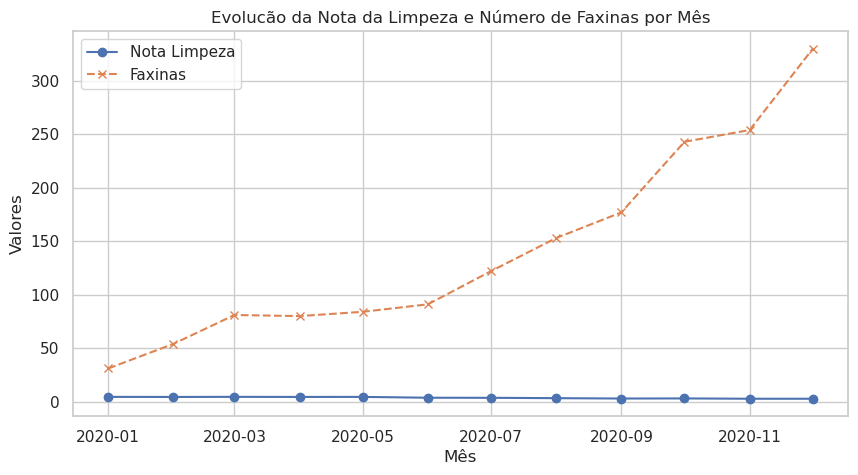

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df['Mês'], df['Nota Limpeza'], marker='o', label='Nota Limpeza')
plt.plot(df['Mês'], df['Faxinas'], marker='x', linestyle='--', label='Faxinas')
plt.title('Evolucão da Nota da Limpeza e Número de Faxinas por Mês')
plt.xlabel('Mês')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.show()

## Análise 2: Correlação entre Faxinas por Morador e Nota de Limpeza

Correlação entre Faxinas por Morador e Nota de Limpeza: 0.94


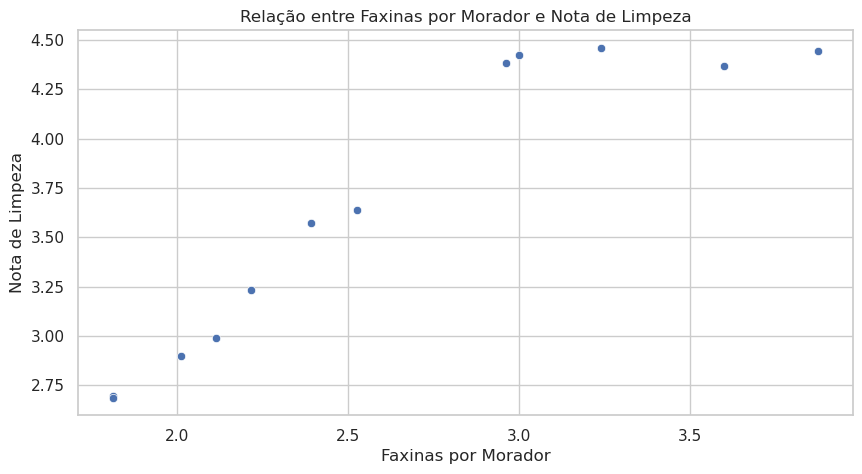

In [12]:
correlacao = df['Faxinas por Morador'].corr(df['Nota Limpeza'])
print(f"Correlação entre Faxinas por Morador e Nota de Limpeza: {correlacao:.2f}")

# Gráfico de dispersão para visualizar a relação
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Faxinas por Morador', y='Nota Limpeza', data=df)
plt.title('Relação entre Faxinas por Morador e Nota de Limpeza')
plt.xlabel('Faxinas por Morador')
plt.ylabel('Nota de Limpeza')
plt.grid(True)
plt.show()

## Análise 3: Identificar meses críticos (nota abaixo de 3)

In [13]:
meses_criticos = df[df['Nota Limpeza'] < 3]
print('Meses críticos com nota de limpeza baixa:')
print(meses_criticos[['Mês', 'Moradores', 'Faxinas', 'Nota Limpeza', 'Faxinas por Morador']])

Meses críticos com nota de limpeza baixa:
          Mês  Moradores  Faxinas  Nota Limpeza  Faxinas por Morador
8  2020-09-01         88      177      2.896516             2.011364
9  2020-10-01        115      243      2.988125             2.113043
10 2020-11-01        140      254      2.694913             1.814286
11 2020-12-01        182      330      2.686223             1.813187


## Análise 4: Evolução do custo por morador


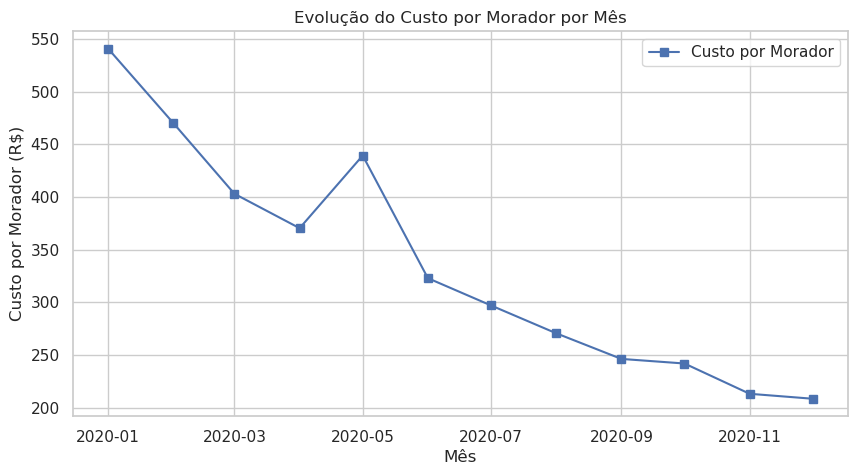

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(df['Mês'], df['Custo por Morador'], marker='s', label='Custo por Morador')
plt.title('Evolução do Custo por Morador por Mês')
plt.xlabel('Mês')
plt.ylabel('Custo por Morador (R$)')
plt.legend()
plt.grid(True)
plt.show()

## Análise 5: Faxineiros Necessários para Meta de 3 Faxinas por Morador

Com base na correlação de 0.94 entre faxinas por morador e satisfação, e considerando o feedback de que a satisfação não aumenta significativamente após 3 faxinas por morador, esta análise calcula quantos faxineiros a mais são necessários para atingir essa meta em cada mês. Assume-se que cada faxineiro realiza, em média, 30 faxinas por mês, com base na produtividade observada nos dados.

In [24]:
meta_por_morador = 3

# Calculando faxinas necessárias para atingir a meta 
df['Faxinas Necessárias (Meta 3)'] = df['Moradores'] * meta_por_morador

# Calculando o déficit de faxinas por mês
df['Déficit de Faxinas (Meta 3)'] = (df['Faxinas Necessárias (Meta 3)'] - df['Faxinas']).clip(lower=0)

# Estimando faxineiros necessários, assumindo 30 faxinas por faxineiro por mês
faxinas_por_faxineiro_mes = 30
df['Faxineiros Adicionais Necessários (Meta 3)'] = (df['Déficit de Faxinas (Meta 3)'] / faxinas_por_faxineiro_mes).round().astype(int)

# Mostrando os Resultaddos 
print('Cálculo de Faxineiros Necessários para Meta de 3 Faxinas por Morador:')
df[['Mês', 'Moradores', 'Faxinas', 'Faxinas Necessárias (Meta 3)', 'Déficit de Faxinas (Meta 3)','Faxineiros Adicionais Necessários (Meta 3)']]



Cálculo de Faxineiros Necessários para Meta de 3 Faxinas por Morador:


,Mês,Moradores,Faxinas,Faxinas Necessárias (Meta 3),Déficit de Faxinas (Meta 3),Faxineiros Adicionais Necessários (Meta 3)
0,2020-01-01,8,31,24,0,0
1,2020-02-01,15,54,45,0,0
2,2020-03-01,25,81,75,0,0
3,2020-04-01,27,80,81,1,0
4,2020-05-01,28,84,84,0,0
5,2020-06-01,36,91,108,17,1
6,2020-07-01,51,122,153,31,1
7,2020-08-01,69,153,207,54,2
8,2020-09-01,88,177,264,87,3
9,2020-10-01,115,243,345,102,3


### Total de faxineiros adicionais necessários no ano (máximo mensal)


In [25]:
total_faxineiros_adicionais = df['Faxineiros Adicionais Necessários (Meta 3)'].max()

print(f'\nNúmero máximo de faxineiros adicionais necessários em um único mês: {total_faxineiros_adicionais}')


Número máximo de faxineiros adicionais necessários em um único mês: 7


## Análise 6: Redistribuição de Faxinas para Equilibrar Frequência

Observando as análise acima percebe-se que existe disparidade significativa na distribuição de faxinas por morador, com valores variando de 3.88 em janeiro a 1.81 em dezembro. Esta análise verifica se é possível redistribuir as faxinas existentes para atingir a meta de 3 faxinas por morador em todos os meses, sem contratações adicionais, calculando o excesso e o déficit de faxinas em cada mês.

In [26]:
# Calculando excesso e déficit de faxinas por morador em relação à meta
df['Excesso de Faxinas por Morador'] = (df['Faxinas por Morador'] - meta_por_morador).clip(lower=0)
df['Déficit de Faxinas por Morador'] = (meta_por_morador - df['Faxinas por Morador']).clip(lower=0)

# Calculando o total de faxinas que podem ser redistribuídas (excesso) e o total necessário (déficit)
total_excesso_faxinas = (df['Excesso de Faxinas por Morador'] * df['Moradores']).sum()
total_deficit_faxinas = (df['Déficit de Faxinas por Morador'] * df['Moradores']).sum()

# Verificando se o excesso cobre o déficit
redistribuicao_possivel = total_excesso_faxinas >= total_deficit_faxinas

In [32]:
# Mostrando os resultados 
print("Análise de Redistribuição de Faxinas para Meta de 3 por Morador:")
print(df[['Mês', 'Moradores', 'Faxinas por Morador', 'Excesso de Faxinas por Morador', 'Déficit de Faxinas por Morador']])
print(f"\n - Total de Faxinas em Excesso (podem ser redistribuídas): {total_excesso_faxinas:.2f} \n")
print(f" - Total de Faxinas em Déficit (necessárias para atingir meta): {total_deficit_faxinas:.2f}\n")
print(f" - Redistribuição Possível sem Contratações Adicionais: {'Sim' if redistribuicao_possivel else 'Não'}\n")

if not redistribuicao_possivel:
    print(" - Como o excesso não cobre o déficit, contratações adicionais ou aumento na produtividade dos faxineiros atuais são necessários para atingir a meta de 3 faxinas por morador em todos os meses.")
else:
    print(" - É possível atingir a meta de 3 faxinas por morador redistribuindo as faxinas existentes, ajustando a alocação nos meses com maior déficit.") 

Análise de Redistribuição de Faxinas para Meta de 3 por Morador:
          Mês  Moradores  Faxinas por Morador  Excesso de Faxinas por Morador  \
0  2020-01-01          8             3.875000                           0.875   
1  2020-02-01         15             3.600000                           0.600   
2  2020-03-01         25             3.240000                           0.240   
3  2020-04-01         27             2.962963                           0.000   
4  2020-05-01         28             3.000000                           0.000   
5  2020-06-01         36             2.527778                           0.000   
6  2020-07-01         51             2.392157                           0.000   
7  2020-08-01         69             2.217391                           0.000   
8  2020-09-01         88             2.011364                           0.000   
9  2020-10-01        115             2.113043                           0.000   
10 2020-11-01        140             1.81428

# Resultados da Análise

Com base nos dados processados e nas vizualizações geradas, aqui são os principais insights:

- **Evolução da Satisfção**: A nota de limpeza cai significativamente ao longo do ano, de valores acima de 4 em janeiro para abaixo de 3 a partir de setembro de 2020, atingindo o menor valor em dezembro (2.69). Isso coincide com o aumento no número de moradores (de 8 em janeiro para 182 em dezembro), enquanto o número de faxinas por morador diminui drasticamente (de 3.88 em janeiro para 1.81 em dezembro). Esse padrão pode estar relacionado ao contexto da pandemia de COVID-19, que intesificou a ocupação de espaçõs residencias devido ao isolamento social e ao trabalho remoto, aumentando a demanda por limpeza nos quartos.

- **Correlação Forte**: Existe uma correlação positiva de 0.94 entre "Faxinas por Morador" e "Nota de Limpeza", indicando que quanto mais faxinas por pessoa, maior satisfação. Isso sugere que a frequência de limpeza não acompanhou o crescimento populacional nos apartamentos, impactando diretamente a percepção de qualidade dos moradores.

- **Meses Críticos**: De setembro a dezembro, as notas ficam consistentemente abaixo de 3, com o menor valor em dezembro(2.69). Nesses meses, o número de faxinas por morador é baixo (abaixo de 2.1), mesmo com um aumento no total de faxinas (de 31 em janeiro para 330 em dezembro). Esse período coincide com o agravamento da pandemia no Brasil, quando medidas de isolamento social estavam em vigor e mais pessoas permaneciam em casa, possivelmente aumentando a necessidade de limpeza.

- **Custo por Morador**: O custo por morador diminui ao longo do ano (de **R\$** 540 em janeiro para **R\$** 208 em dezembro), sugerindo que o aumento de faxinas não acompanhou o crescimento proporcionalmente o crescimento de moradores, impactando a satisfação.

- **Necessidade de Faxineiros Adicionais**: Para atingir a meta de 3 faxinas por morador, calculou-se um déficit máximo de 216 faxinas em dezembro, exigindo até 7 faxineiros adicionais (assumindo uma produtividade média de 30 faxinas por faxineiro mês). Nos primeiros meses (janeiro a maio), não há déficit, pois a frequência já está acima da meta.

- **Redistribuição de Faxinas**: A análise de redistribuição mostra uma disparidade significativa na frequência de faxinas por morador (de 3.88 em janeiro a 1.81 em dezembro). O total de faxinas em excesso nos primeiros meses (22 faxinas) não cobre o déficit total de 674 faxinas em ao longo do ano, especialmente nos meses críticos de setembro a dezembro. Isso indica que a redistribuição sozinha não é suficiente para atingir a meta de 3 faxinas por morador em todos os meses.

# Recomendações para o Time de finanças 

Com base na análise dos dados e no contexto da pandemia e do mercado imobiliário em 2020, aqui estão as recomendações:

- **Considerando do Contexto Pandêmico**: Dado que 2020 foi um ano atípico, com isolamento social e aumento da permancência em casa, considere que a demanda por limpeza pode ser temporariamente maior. Avalie se o crescimento de moradores é uma tendência de longo prazo (influenciada pelo mercado imobiliário) ou um efeito passageiro da pandemia, ajustando contratações conforme o necessário.

- **Contratação de Novas Faxineiras**: Recomendo a contratação temporária de 3 a 7 faxineiras, na modalidade freelance ou por demanda, para atingir a meta de 3 faxinas por morador, especialmente nos meses críticos (setembro a dezembro). A correlação de 0.94 entre faxinas por morador e satisfação indica que mais faxinas por pessoa melhoram a percepção de limpeza. A simulação mostra que até 7 faxineiros adicionais são necessários em dezembro (déficit de 216 faxinas), mas 3 já cobririam parte significativa do déficit em meses anteriores. Essa abordagem permite ajustar a mão de obra conforme a necessidade, sem comprometer a empresa com custos fixos de longo prazo, pagando apenas pelas faxinas realizadas ou por contratos de curta duração nesses períodos de maior demanda.

- **Metas de Faxinas por Morador**: Estabelecer uma meta mínima de 3 faxinas por morador por mês, já que a satisfação não aumenta significativamente acima disso, conforme feedback recebido. Essa meta ajudará a manter a satisfação em níveis aceitáveis, mesmo com o aumento de moradores, que pode estar relacionado a mudanças no mercado imobiliário e à pandemia.

- **Redistribuição de Faxinas**: Embora a redistribuição das faxinas existentes não seja suficiente para cobrir o déficit total (excesso de 22 contra déficit de 674 faxinas), ajustar a alocação nos meses com maior excesso (janeira a março) para os meses críticos pode reduzir a necessidade de contratações. Combinar essa estratégia com contratações temporárias para otimizar custos será benéfico.

- **Otimização de Custos**: Embora o custo por morador tenha diminuído (de **R\$** 540 para **R\$** 208), a satisfação caiu drasticamente. Um aumento controlado no orçamento para faxinas (mantendo o custo por faxina entre **R\$** 115 e **R\$** 140) pode ser justificado para melhorar as notas sem impactar excessivamente as finanças.

- **Campanhas de Consientização**: Como a mediada complementar, promover ações educativas com os moradores para reduzir a demanda por limpeza (ex:.regras de uso de áreas comuns), pode ser algo que vai ajudar a satisfação dos moradores e dimuinui uma parte da pressão sobre o time de faxinas.

# Dados Adicionais que Seriam Úteis

Para uma análise mais completa, os seguintes dados seriam benéficos:

- **Localização Específica dos Apartamentos**: Saber em qual estado ou cidade (ex.: São Paulo, Rio de Janeiro) os dados foram coletados permitiria contextualizar melhor os impactos da pandemia e do mercado imobiliário. Por exemplo, o Sudeste teve maior recuperação no setor imobiliário, enquanto o Sul enfrentou quedas significativas, segundo a [CBIC - Câmara Brasileira da Indústria da Construção](https://cbic.org.br/vendas-de-imoveis-no-brasil-sobem-84-em-2020-mesmo-sob-impacto-da-covid-19-2/).

- **Horas Trabalhadas por Faxineira**: Informações sobre a carga horária e produtividade de cada faxineiro ajudariam a avaliar se a equipe atual está sobrecarregada ou se há ineficiência na alocação.

- **Motivos Específicos da Insatisfação:** Informações sobre a qualidade dos produtos de limpeza utilizados, atenção dos faxineiros aos detalhes, possíveis danos a utensílios durante a limpeza, e o atendimento prestado pelos faxineiros ajudariam a identificar se a insatisfação está relacionada à frequência ou a outros fatores de qualidade.

- **Distribuição de Moradores por Quarto**: Entender se há quartos superlotados ajudaria a priorizar limpezas em áreas de maior uso.

- **Sazonalidade e Eventos**: Informações sobre períodos de alta rotatividade ou eventos (ex.: férias, feriados, lockdowns locais durante a pandemia) explicariam picos de moradores ou demanda por limpeza.

